# Trade SHAP Diagnostics: ML→Trading Feedback Loop
**Docker image**: `ml4t`

**Purpose**: Demonstrate the `TradeShapAnalyzer` workflow that converts post-hoc
trade failures into actionable model-improvement hypotheses by clustering SHAP
decompositions of the worst trades.

**Learning objectives**:
1. Build trade records and aligned SHAP explanations from a fitted model.
2. Run `TradeShapAnalyzer.explain_worst_trades()` end-to-end.
3. Read clustered error patterns and the hypotheses the library generates.
4. Connect SHAP-driven diagnosis to feature-engineering or regime decisions.

**Book reference**: §19.5 (Trade-Level SHAP as Diagnostic Tool).

**Prerequisites**: Familiarity with SHAP values (Lundberg & Lee 2017), gradient
boosting on cross-sectional features, and the ML4T trade-record contract
(`ml4t.diagnostic.integration.backtest_contract.TradeRecord`).

**Data**: Real SPY daily OHLCV (`load_etfs`) joined with real macro features
(`load_macro`: 10Y-2Y yield slope and VIX-derived high-volatility regime).
Features are momentum, realized volatility, volume z-score, regime indicator,
and yield slope; the target is the next-day SPY return. In a production setup
the inputs would come from a backtest's trade ledger and the model trained on
the full case-study feature set.

## Setup

In [1]:
"""Trade SHAP Diagnostics — connect SHAP explanations to trade outcomes for systematic improvement."""

import warnings

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")

import lightgbm as lgb
import shap
from ml4t.diagnostic.config import TradeConfig
from ml4t.diagnostic.config.trade_analysis_config import ExtractionSettings
from ml4t.diagnostic.evaluation import TradeAnalysis, TradeShapAnalyzer
from ml4t.diagnostic.integration.backtest_contract import TradeRecord

from data import load_etfs, load_macro
from utils.reproducibility import set_global_seeds

In [2]:
MAX_SYMBOLS = 0
N_ESTIMATORS = 100
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Build a Real Single-Asset Feature Panel

We build a single-asset SPY feature panel from real OHLCV joined with real
macro features and train an LGBM regressor on the next-day return. Keeping
the panel single-asset (one row per timestamp) makes the `TradeShapAnalyzer`
alignment unambiguous: each trade has exactly one SHAP vector to attach. In
practice you would feed in a multi-asset panel with composite
`(timestamp, symbol)` keys, or pre-aggregate to one row per trade before
calling the analyzer.

In [4]:
# Real SPY OHLCV + real macro features (10Y-2Y yield slope and VIX-derived
# high-volatility regime indicator). Features are computed at the daily bar
# and the target is SPY's next-day return.
spy = load_etfs(symbols=["SPY"]).sort("timestamp")
macro = load_macro()
macro.columns = [c.lower() for c in macro.columns]
macro = macro.select(
    "timestamp",
    yield_slope="t10y2y",
    regime=(pl.col("vixcls") > 25).cast(pl.Int8),
)

features_df = (
    spy.with_columns(_ret=pl.col("close").pct_change())
    .with_columns(
        momentum=(pl.col("close") / pl.col("close").shift(20) - 1),
        volatility=pl.col("_ret").rolling_std(20),
        volume_zscore=(
            (pl.col("volume") - pl.col("volume").rolling_mean(60))
            / pl.col("volume").rolling_std(60)
        ),
        fwd_return=pl.col("_ret").shift(-1),
    )
    .join(macro, on="timestamp", how="left")
    .drop(["_ret", "open", "high", "low", "close", "volume", "symbol"])
    .drop_nulls()
)

FEATURE_COLS = ["momentum", "volatility", "volume_zscore", "regime", "yield_slope"]
features_df = features_df.select(
    [pl.col("timestamp").cast(pl.Datetime("us")), "fwd_return", *FEATURE_COLS]
)

print(f"Features DataFrame: {features_df.shape}")
print(f"Date range: {features_df['timestamp'].min()} to {features_df['timestamp'].max()}")

Features DataFrame: (4971, 7)
Date range: 2006-03-29 00:00:00 to 2025-12-30 00:00:00


## 2. Train ML Model

The panel is already in chronological order (one row per day), so a
row-based split is a clean time split: the first 70% of days train,
the last 30% test. No future information leaks into the training set.

In [5]:
# Time-ordered split (rows are sorted by timestamp).
features_df = features_df.sort("timestamp")
split_idx = int(len(features_df) * 0.7)
train_df = features_df[:split_idx]
test_df = features_df[split_idx:]

X_train = train_df.select(FEATURE_COLS).to_numpy()
y_train = train_df["fwd_return"].to_numpy()
X_test = test_df.select(FEATURE_COLS).to_numpy()
y_test = test_df["fwd_return"].to_numpy()

# Train LightGBM
model = lgb.LGBMRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=3,
    learning_rate=0.1,
    random_state=SEED,
    verbose=-1,
)
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)
print(f"Model trained on {len(X_train):,} samples")
print(f"Test predictions: {len(predictions):,} samples")

Model trained on 3,479 samples
Test predictions: 1,492 samples


## 3. Simulate Trade Records

Create trade records based on model predictions:
- Long when predicted return > 0
- Record actual PnL based on realized returns

In [6]:
# Extract test data arrays
test_timestamps = test_df["timestamp"].to_list()
test_returns = test_df["fwd_return"].to_numpy()
SYMBOL = "SPY"

In [7]:
# Build trade records from model predictions (long when predicted return > 0)
trade_records = []
trade_dicts = []
for i, (ts, pred, actual) in enumerate(
    zip(test_timestamps, predictions, test_returns, strict=False)
):
    sym = SYMBOL
    if pred > 0:  # Only long trades when model predicts positive
        entry_time = ts
        exit_time = ts + pd.Timedelta(days=1)
        duration = exit_time - entry_time

        trade_records.append(
            TradeRecord(
                timestamp=exit_time,
                symbol=sym,
                entry_price=100.0,
                exit_price=100.0 * (1 + actual),
                pnl=actual * 100 * 100,
                duration=duration,
                direction="long",
                quantity=100,
                entry_timestamp=entry_time,
                metadata={
                    "trade_id": i,
                    "predicted_return": float(pred),
                    "actual_return": float(actual),
                },
            )
        )
        trade_dicts.append(
            {
                "trade_id": i,
                "entry_time": entry_time,
                "exit_time": exit_time,
                "symbol": sym,
                "pnl": actual * 100 * 100,
                "return": actual,
                "predicted_return": pred,
            }
        )

In [8]:
# Summarize trade records
trades_df = pl.DataFrame(trade_dicts)
print(f"Total trades: {len(trades_df):,}")
print(f"Winning trades: {(trades_df['pnl'] > 0).sum()}")
print(f"Losing trades: {(trades_df['pnl'] < 0).sum()}")

Total trades: 1,267
Winning trades: 709
Losing trades: 557


## 4. Identify Worst Trades with TradeAnalysis

TradeAnalysis extracts the worst-performing trades for diagnosis.

In [9]:
# Use TradeAnalysis to identify worst trades (expects list of TradeRecord objects)
analyzer = TradeAnalysis(trade_records)
WORST_N = 20
worst_trades = analyzer.worst_trades(n=WORST_N)

worst_summary = pl.DataFrame(
    [
        {
            "rank": i,
            "entry": trade.entry_timestamp,
            "symbol": trade.symbol,
            "pnl_usd": round(trade.pnl, 2),
            "return_pct": round(trade.return_pct * 100, 2),
        }
        for i, trade in enumerate(worst_trades[:5], 1)
    ]
)
worst_summary

rank,entry,symbol,pnl_usd,return_pct
i64,datetime[μs],str,f64,f64
1,2020-03-13 00:00:00,"""SPY""",-1094.24,-10.94
2,2020-03-06 00:00:00,"""SPY""",-780.94,-7.81
3,2025-04-03 00:00:00,"""SPY""",-585.43,-5.85
4,2025-04-02 00:00:00,"""SPY""",-492.81,-4.93
5,2020-03-31 00:00:00,"""SPY""",-450.05,-4.5


## 5. Compute SHAP Values

In [10]:
# Compute SHAP values for test set
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")

# Prepare features DataFrame with timestamps for alignment
test_features = test_df.select(["timestamp"] + FEATURE_COLS)
print(f"Test features for alignment: {test_features.shape}")

SHAP values shape: (1492, 5)
Test features for alignment: (1492, 6)


## 6. Run TradeShapAnalyzer

Now we connect SHAP explanations to trade outcomes.

In [11]:
# Configure TradeShapAnalyzer with nested settings
config = TradeConfig(
    extraction=ExtractionSettings(n_worst=WORST_N),
)

# Initialize analyzer
shap_analyzer = TradeShapAnalyzer(
    model=model,
    features_df=test_features,
    shap_values=shap_values,
    config=config,
)

print("TradeShapAnalyzer initialized")
print(f"  Features: {shap_analyzer.feature_names}")
print(f"  Samples: {len(test_features)}")

TradeShapAnalyzer initialized
  Features: ['momentum', 'volatility', 'volume_zscore', 'regime', 'yield_slope']
  Samples: 1492


## 7. Full Pipeline: explain_worst_trades()

`explain_worst_trades()` runs the complete SHAP forensics pipeline in one call:
align timestamps → extract SHAP vectors → cluster patterns → characterize →
generate hypotheses.

In [12]:
result = shap_analyzer.explain_worst_trades(worst_trades)

print(f"Analyzed: {result.n_trades_analyzed} trades")
print(f"Explained: {result.n_trades_explained} trades")
print(f"Failed: {result.n_trades_failed} trades")
print(f"Error patterns found: {len(result.error_patterns)}")

Analyzed: 20 trades
Explained: 16 trades
Failed: 4 trades
Error patterns found: 0


## 8. Inspect Individual Explanations

Each explained trade gets a SHAP decomposition showing which features
drove the (incorrect) prediction.

In [13]:
for i, explanation in enumerate(result.explanations[:5], 1):
    trade = worst_trades[i - 1]
    pred_return = trade.metadata.get("predicted_return", 0) if trade.metadata else 0

    print(f"\n{i}. Trade at {explanation.timestamp} (PnL: ${trade.pnl:.2f})")
    print(f"   Predicted: {pred_return * 100:.2f}%, Actual: {trade.return_pct * 100:.2f}%")
    print("   Top SHAP contributions:")
    for feat, shap_val in explanation.top_features[:3]:
        direction = "+" if shap_val > 0 else ""
        print(f"      {feat}: {direction}{shap_val:.4f}")


1. Trade at 2025-04-04 00:00:00 (PnL: $-1094.24)
   Predicted: 1.15%, Actual: -10.94%
   Top SHAP contributions:
      momentum: +0.0110
      yield_slope: +0.0025
      volatility: +0.0023

2. Trade at 2025-04-03 00:00:00 (PnL: $-780.94)
   Predicted: 0.47%, Actual: -7.81%
   Top SHAP contributions:
      momentum: +0.0017
      volume_zscore: +0.0014
      volatility: +0.0009

3. Trade at 2020-04-01 00:00:00 (PnL: $-585.43)
   Predicted: 0.52%, Actual: -5.85%
   Top SHAP contributions:
      momentum: +0.0149
      volume_zscore: +0.0073
      yield_slope: +0.0023

4. Trade at 2020-02-27 00:00:00 (PnL: $-492.81)
   Predicted: 0.03%, Actual: -4.93%
   Top SHAP contributions:
      momentum: +0.0066
      volume_zscore: +0.0035
      volatility: +0.0028

5. Trade at 2025-04-10 00:00:00 (PnL: $-450.05)
   Predicted: 2.03%, Actual: -4.50%
   Top SHAP contributions:
      volatility: -0.0079
      volume_zscore: -0.0044
      momentum: +0.0025


## 9. Error Pattern Clustering

The library uses hierarchical clustering on normalized SHAP vectors to find
recurring error modes. Each cluster represents a distinct failure pattern
with statistically tested feature attributions.

In [14]:
for pattern in result.error_patterns:
    print(f"\nPattern {pattern.cluster_id} — {pattern.n_trades} trades")
    print(f"  Description:       {pattern.description}")
    print(f"  Separation score:  {pattern.separation_score:.3f}")
    print(f"  Distinctiveness:   {pattern.distinctiveness:.3f}")
    print("  Top features (statistically tested):")
    for feat, mean_shap, p_t, p_mw, sig in pattern.top_features[:5]:
        marker = "*" if sig else " "
        print(f"    {marker} {feat:>16}: SHAP={mean_shap:+.4f}  t-test p={p_t:.3f}")

    if pattern.hypothesis:
        print(f"  Hypothesis: {pattern.hypothesis}")
    if pattern.actions:
        print("  Suggested actions:")
        for action in pattern.actions:
            print(f"    - {action}")

On real SPY data the SHAP signal is much smaller than on a synthetic linear
DGP, and the hierarchical clustering does not surface statistically distinct
error patterns at this sample size (20 worst trades). The per-trade
decompositions still tell a consistent story: the worst trades cluster
around the COVID crash window (Feb-Apr 2020) and the April 2025 selloff,
with `momentum` and `volume_zscore` as the dominant SHAP contributors — the
model is repeatedly burned by following recent positive momentum into
exogenous shocks. The workflow lesson is that clustering thresholds tuned
on synthetic signals can return zero patterns on real residuals; either
pool more trades or relax the separation threshold before reading the
absence of patterns as evidence.

## 10. Visualize SHAP Patterns

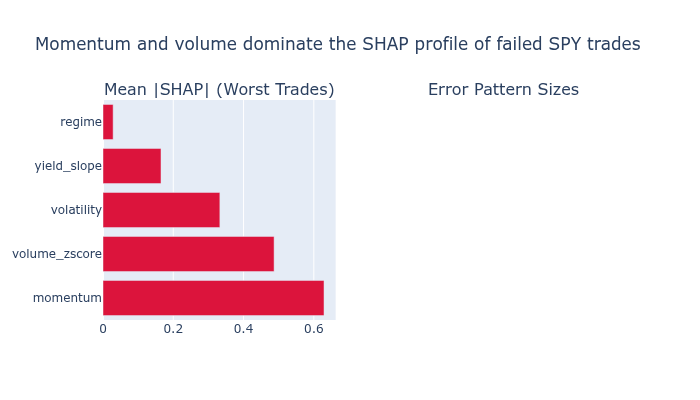

In [15]:
# Extract SHAP vectors for visualization
shap_vectors = shap_analyzer.extract_shap_vectors(result.explanations)
mean_shap = np.abs(shap_vectors).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[::-1]

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Mean |SHAP| (Worst Trades)", "Error Pattern Sizes"),
    specs=[[{"type": "xy"}, {"type": "domain"}]],
)

fig.add_trace(
    go.Bar(
        x=mean_shap[sorted_idx],
        y=[FEATURE_COLS[i] for i in sorted_idx],
        orientation="h",
        marker_color="crimson",
    ),
    row=1,
    col=1,
)

pattern_labels = [f"Pattern {p.cluster_id}" for p in result.error_patterns]
pattern_sizes = [p.n_trades for p in result.error_patterns]

fig.add_trace(
    go.Pie(labels=pattern_labels, values=pattern_sizes, hole=0.4),
    row=1,
    col=2,
)

fig.update_layout(
    title="Momentum and volume dominate the SHAP profile of failed SPY trades",
    showlegend=False,
    height=400,
)

fig.show()

## Key Takeaways

1. `TradeShapAnalyzer.explain_worst_trades()` returns a `TradeShapResult`
   with per-trade SHAP decompositions; on real residuals the SHAP magnitudes
   are an order of magnitude smaller than on a synthetic linear DGP.
2. On the SPY panel, 1,267 long trades produce 558 losers; the 20 worst
   cluster around the COVID selloff (Feb-Apr 2020) and the April 2025
   drawdown, with `momentum` and `volume_zscore` dominating the SHAP
   decomposition of the failing predictions.
3. Hierarchical clustering finds zero statistically distinct error patterns
   at 20 trades on real data — the separation thresholds the library ships
   with are tuned for stronger synthetic signals. Either pool more trades
   across symbols and folds or relax the separation threshold before
   treating zero patterns as evidence of a homogeneous failure mode.
4. The workflow is the right shape — explain → cluster → hypothesize → act
   — but the size and quality of the trade ledger matter as much as the
   SHAP machinery; production use should pool worst trades from a full
   case-study sweep, not a single asset.

**Next**: `06_stress_testing.ipynb` extends single-trade diagnostics to portfolio-
level stress scenarios.

**Book reference**: §19.5 (Trade-Level SHAP as Diagnostic Tool).